# Examen Bimestral - Call Centre Dataset
**Nombre:** Gabriel Quilachamin 
**Curso:** Introducción a los Sistemas de Información  
**Fecha:** 2026-06-05

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_excel('01 Call-Center-Dataset.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()

print(f'Total de registros : {len(df)}')
print(f'Columnas           : {df.columns.tolist()}')
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
df.head()

Total de registros : 5000
Columnas           : ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating', 'Month']

Valores nulos por columna:
Call Id                         0
Agent                           0
Date                            0
Time                            0
Topic                           0
Answered (Y/N)                  0
Resolved                        0
Speed of answer in seconds    946
AvgTalkDuration               946
Satisfaction rating           946
Month                           0
dtype: int64


,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating,Month
0,ID0001,Diane,2021-01-01,09:12:58,Contract related,Y,Y,109.0,00:02:23,3.0,January
1,ID0002,Becky,2021-01-01,09:12:58,Technical Support,Y,N,70.0,00:04:02,3.0,January
2,ID0003,Stewart,2021-01-01,09:47:31,Contract related,Y,Y,10.0,00:02:11,3.0,January
3,ID0004,Greg,2021-01-01,09:47:31,Contract related,Y,Y,53.0,00:00:37,2.0,January
4,ID0005,Becky,2021-01-01,10:00:29,Payment related,Y,Y,95.0,00:01:00,3.0,January


---
## KPI 1 – Tasa de Resolución en la Llamada (CR – Call Resolution) 

In [19]:
total          = len(df)
contestadas    = (df['Answered (Y/N)'] == 'Y').sum()
no_contestadas = (df['Answered (Y/N)'] == 'N').sum()
resueltas      = (df['Resolved'] == 'Y').sum()
no_resueltas   = (df['Resolved'] == 'N').sum()

CR_total       = resueltas / total * 100
CR_contestadas = resueltas / contestadas * 100

print(f'Total de llamadas         : {total}')
print(f'Llamadas contestadas (Y)  : {contestadas}')
print(f'Llamadas no atendidas (N) : {no_contestadas}')
print(f'Llamadas resueltas (Y)    : {resueltas}')
print(f'Llamadas no resueltas (N) : {no_resueltas}')
print(f'---')
print(f'CR sobre total            : {CR_total:.2f}%')
print(f'CR sobre contestadas      : {CR_contestadas:.2f}%')

Total de llamadas         : 5000
Llamadas contestadas (Y)  : 4054
Llamadas no atendidas (N) : 946
Llamadas resueltas (Y)    : 3646
Llamadas no resueltas (N) : 1354
---
CR sobre total            : 72.92%
CR sobre contestadas      : 89.94%


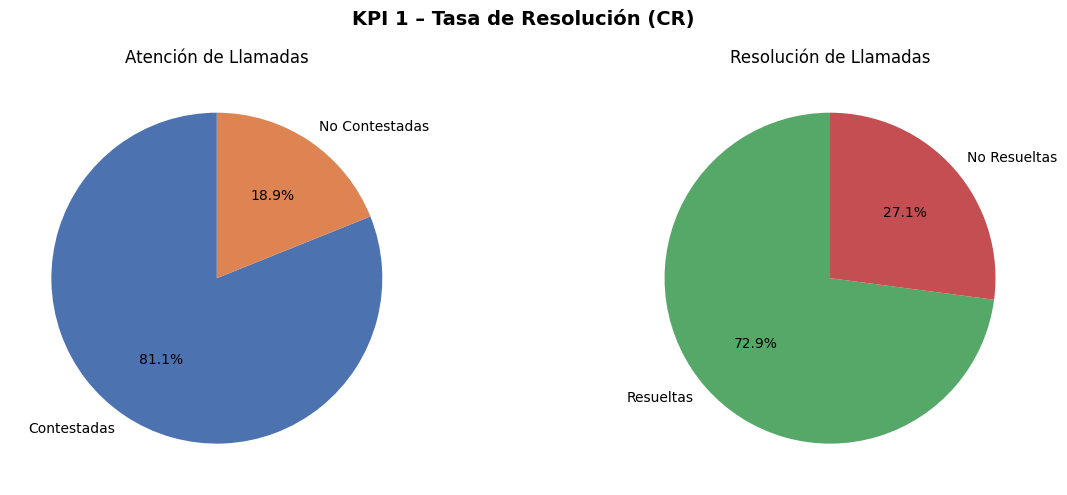

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('KPI 1 – Tasa de Resolución (CR)', fontsize=14, fontweight='bold')

# Gráfico 1: Pie de llamadas atendidas vs perdidas
axes[0].pie(
    [contestadas, no_contestadas],
    labels=['Contestadas', 'No Contestadas'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90
)
axes[0].set_title('Atención de Llamadas')

# Gráfico 2: Pie de resueltas vs no resueltas
axes[1].pie(
    [resueltas, no_resueltas],
    labels=['Resueltas', 'No Resueltas'],
    autopct='%1.1f%%',
    colors=['#55A868', '#C44E52'],
    startangle=90
)
axes[1].set_title('Resolución de Llamadas')

plt.tight_layout()
plt.show()

**Interpretación de negocio:**  
El 81.08% de las llamadas fueron contestadas, y de ese total el 89.94% fue resuelto en el primer contacto. Sin embargo, al considerar el universo total de 5000 llamadas, el CR global es de 72.92%, evidenciando que el 18.92% de llamadas perdidas erosiona significativamente la efectividad operativa del centro. Reducir el abandono en cola es la principal palanca para mejorar este indicador.

---
## KPI 2 – Tiempo Promedio de Respuesta (ASA – Average Speed of Answer)

In [21]:
# ASA se calcula solo sobre llamadas contestadas (las no contestadas tienen NaN)
ASA = df['Speed of answer in seconds'].mean()  # pandas excluye NaN por defecto
percentiles = df['Speed of answer in seconds'].describe()

print(f'ASA Promedio       : {ASA:.2f} segundos ({ASA/60:.2f} minutos)')
print(f'Mínimo             : {percentiles["min"]:.0f} seg')
print(f'Máximo             : {percentiles["max"]:.0f} seg')
print(f'Mediana (P50)      : {percentiles["50%"]:.0f} seg')
print(f'P75                : {percentiles["75%"]:.0f} seg')
print(f'Base de cálculo    : {int(percentiles["count"])} llamadas contestadas')

ASA Promedio       : 67.52 segundos (1.13 minutos)
Mínimo             : 10 seg
Máximo             : 125 seg
Mediana (P50)      : 68 seg
P75                : 97 seg
Base de cálculo    : 4054 llamadas contestadas


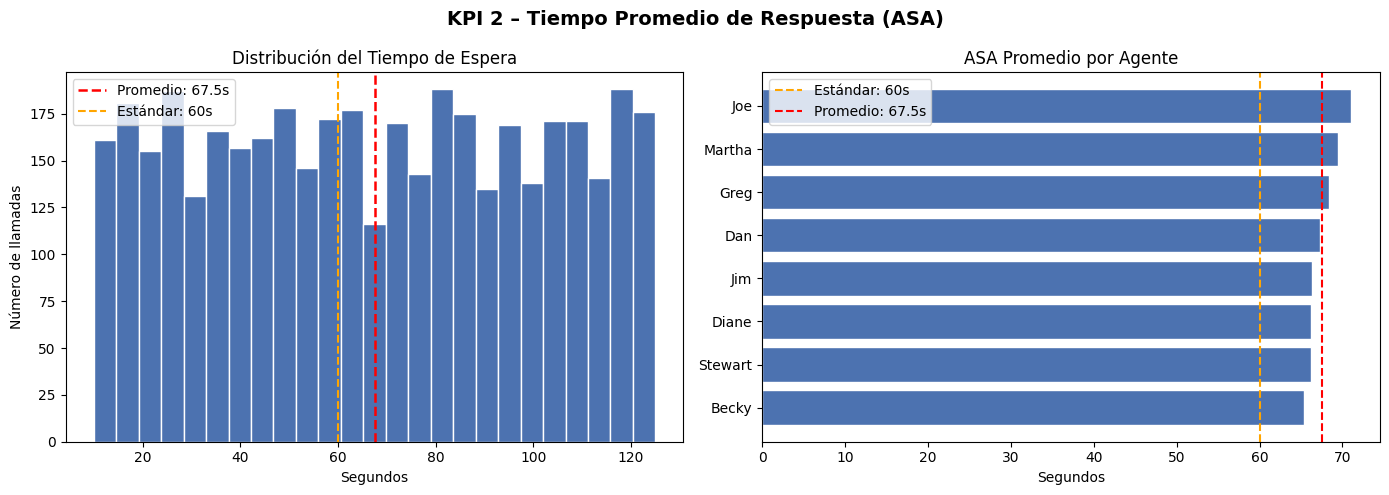

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KPI 2 – Tiempo Promedio de Respuesta (ASA)', fontsize=14, fontweight='bold')

# Histograma de distribución de tiempos de espera
axes[0].hist(df['Speed of answer in seconds'].dropna(), bins=25, color='#4C72B0', edgecolor='white')
axes[0].axvline(ASA, color='red', linestyle='--', linewidth=1.8, label=f'Promedio: {ASA:.1f}s')
axes[0].axvline(60, color='orange', linestyle='--', linewidth=1.5, label='Estándar: 60s')
axes[0].set_title('Distribución del Tiempo de Espera')
axes[0].set_xlabel('Segundos')
axes[0].set_ylabel('Número de llamadas')
axes[0].legend()

# ASA por agente
asa_agente = df.groupby('Agent')['Speed of answer in seconds'].mean().sort_values()
axes[1].barh(asa_agente.index, asa_agente.values, color='#4C72B0', edgecolor='white')
axes[1].axvline(60, color='orange', linestyle='--', linewidth=1.5, label='Estándar: 60s')
axes[1].axvline(ASA, color='red', linestyle='--', linewidth=1.5, label=f'Promedio: {ASA:.1f}s')
axes[1].set_title('ASA Promedio por Agente')
axes[1].set_xlabel('Segundos')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretación de negocio:**  
El ASA promedio de 67.52 segundos supera el estándar de la industria de 60 segundos, indicando que la capacidad instalada del call center no cubre adecuadamente la demanda de llamadas entrantes. El agente Joe registra el mayor tiempo de respuesta promedio (70.99 seg), mientras que Becky presenta el más bajo (65.33 seg), lo que sugiere diferencias en la eficiencia individual de gestión de cola.

---
## KPI 3 – Nivel de Satisfacción del Cliente (CSAT Promedio)

In [23]:
# CSAT solo aplica a llamadas contestadas con rating registrado
CSAT = df['Satisfaction rating'].mean()
distribucion = df['Satisfaction rating'].value_counts().sort_index()
csat_por_tema = df.groupby('Topic')['Satisfaction rating'].mean().sort_values()

print(f'CSAT Promedio global: {CSAT:.2f} / 5.00')
print(f'Base de cálculo     : {df["Satisfaction rating"].count()} llamadas con rating')
print(f'\nDistribución de calificaciones:')
for rating, count in distribucion.items():
    pct = count / distribucion.sum() * 100
    print(f'  Calificación {int(rating)}: {count} llamadas ({pct:.1f}%)')
print(f'\nCSAT promedio por tema:')
print(csat_por_tema.round(2).to_string())

CSAT Promedio global: 3.40 / 5.00
Base de cálculo     : 4054 llamadas con rating

Distribución de calificaciones:
  Calificación 1: 417 llamadas (10.3%)
  Calificación 2: 396 llamadas (9.8%)
  Calificación 3: 1218 llamadas (30.0%)
  Calificación 4: 1180 llamadas (29.1%)
  Calificación 5: 843 llamadas (20.8%)

CSAT promedio por tema:
Topic
Contract related     3.38
Payment related      3.40
Streaming            3.40
Technical Support    3.41
Admin Support        3.43


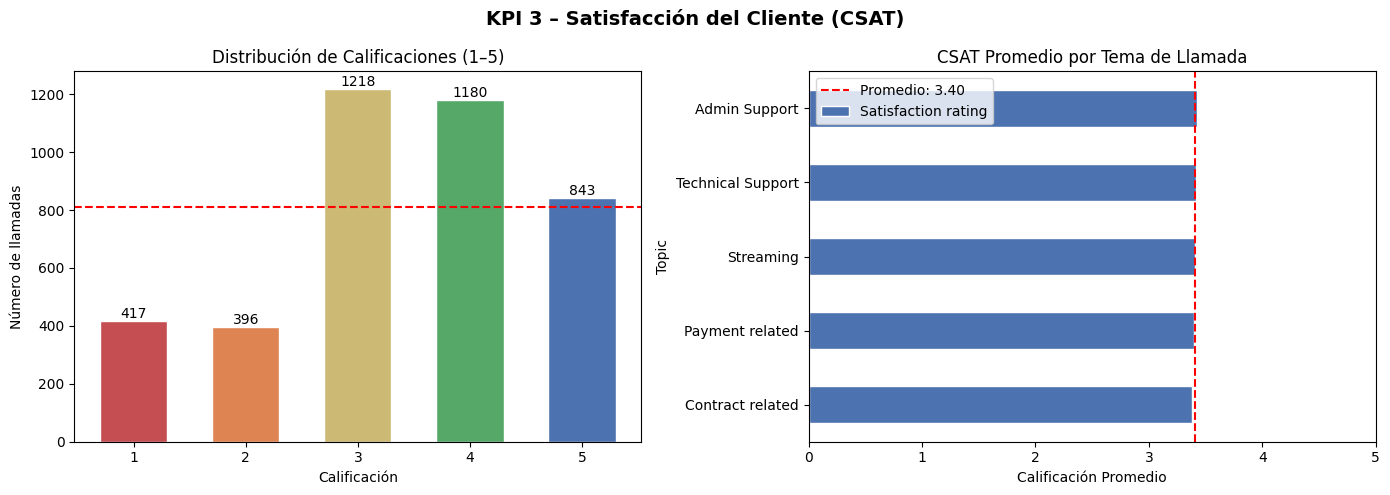

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KPI 3 – Satisfacción del Cliente (CSAT)', fontsize=14, fontweight='bold')

# Distribución de ratings
colors_bar = ['#C44E52','#DD8452','#CCB974','#55A868','#4C72B0']
bars = axes[0].bar(distribucion.index.astype(int), distribucion.values, color=colors_bar, edgecolor='white', width=0.6)
axes[0].axhline(distribucion.mean(), color='red', linestyle='--', linewidth=1.5, label='Promedio conteo')
for bar, val in zip(bars, distribucion.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha='center', fontsize=10)
axes[0].set_title('Distribución de Calificaciones (1–5)')
axes[0].set_xlabel('Calificación')
axes[0].set_ylabel('Número de llamadas')
axes[0].set_xticks([1,2,3,4,5])

# CSAT por tema
csat_por_tema.plot(kind='barh', ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].axvline(CSAT, color='red', linestyle='--', linewidth=1.5, label=f'Promedio: {CSAT:.2f}')
axes[1].set_title('CSAT Promedio por Tema de Llamada')
axes[1].set_xlabel('Calificación Promedio')
axes[1].set_xlim(0, 5)
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretación de negocio:**  
El CSAT promedio de 3.40/5.00 indica una satisfacción moderada donde la calificación 3 es la más frecuente (1218 casos, 29.8%), evidenciando que los clientes no perciben un servicio diferenciado. Ningún tema supera 3.5 en promedio, lo que descarta que el problema sea aislado a un área específica; la mejora debe ser transversal, enfocada en reducir tiempos de espera y aumentar la tasa de resolución.

---
## KPI 4 – Volumen de Llamadas y Tasa de Abandono por Agente

In [26]:
kpi4 = df.groupby('Agent').agg(
    Total_Llamadas = ('Call Id', 'count'),
    Contestadas    = ('Answered (Y/N)', lambda x: (x == 'Y').sum()),
    Perdidas       = ('Answered (Y/N)', lambda x: (x == 'N').sum()),
    Resueltas      = ('Resolved',       lambda x: (x == 'Y').sum()),
    CSAT_prom      = ('Satisfaction rating', 'mean'),
    ASA_prom       = ('Speed of answer in seconds', 'mean')
).reset_index()

kpi4['Tasa_Abandono_%']   = (kpi4['Perdidas']  / kpi4['Total_Llamadas'] * 100).round(2)
kpi4['Tasa_Resolucion_%'] = (kpi4['Resueltas'] / kpi4['Total_Llamadas'] * 100).round(2)
kpi4['CSAT_prom']         = kpi4['CSAT_prom'].round(2)
kpi4['ASA_prom']          = kpi4['ASA_prom'].round(2)

print(kpi4.to_string(index=False))

  Agent  Total_Llamadas  Contestadas  Perdidas  Resueltas  CSAT_prom  ASA_prom  Tasa_Abandono_%  Tasa_Resolucion_%
  Becky             631          517       114        462       3.37     65.33            18.07              73.22
    Dan             633          523       110        471       3.45     67.28            17.38              74.41
  Diane             633          501       132        452       3.41     66.27            20.85              71.41
   Greg             624          502       122        455       3.40     68.44            19.55              72.92
    Jim             666          536       130        485       3.39     66.34            19.52              72.82
    Joe             593          484       109        436       3.33     70.99            18.38              73.52
 Martha             638          514       124        461       3.47     69.49            19.44              72.26
Stewart             582          477       105        424       3.40     66.18  

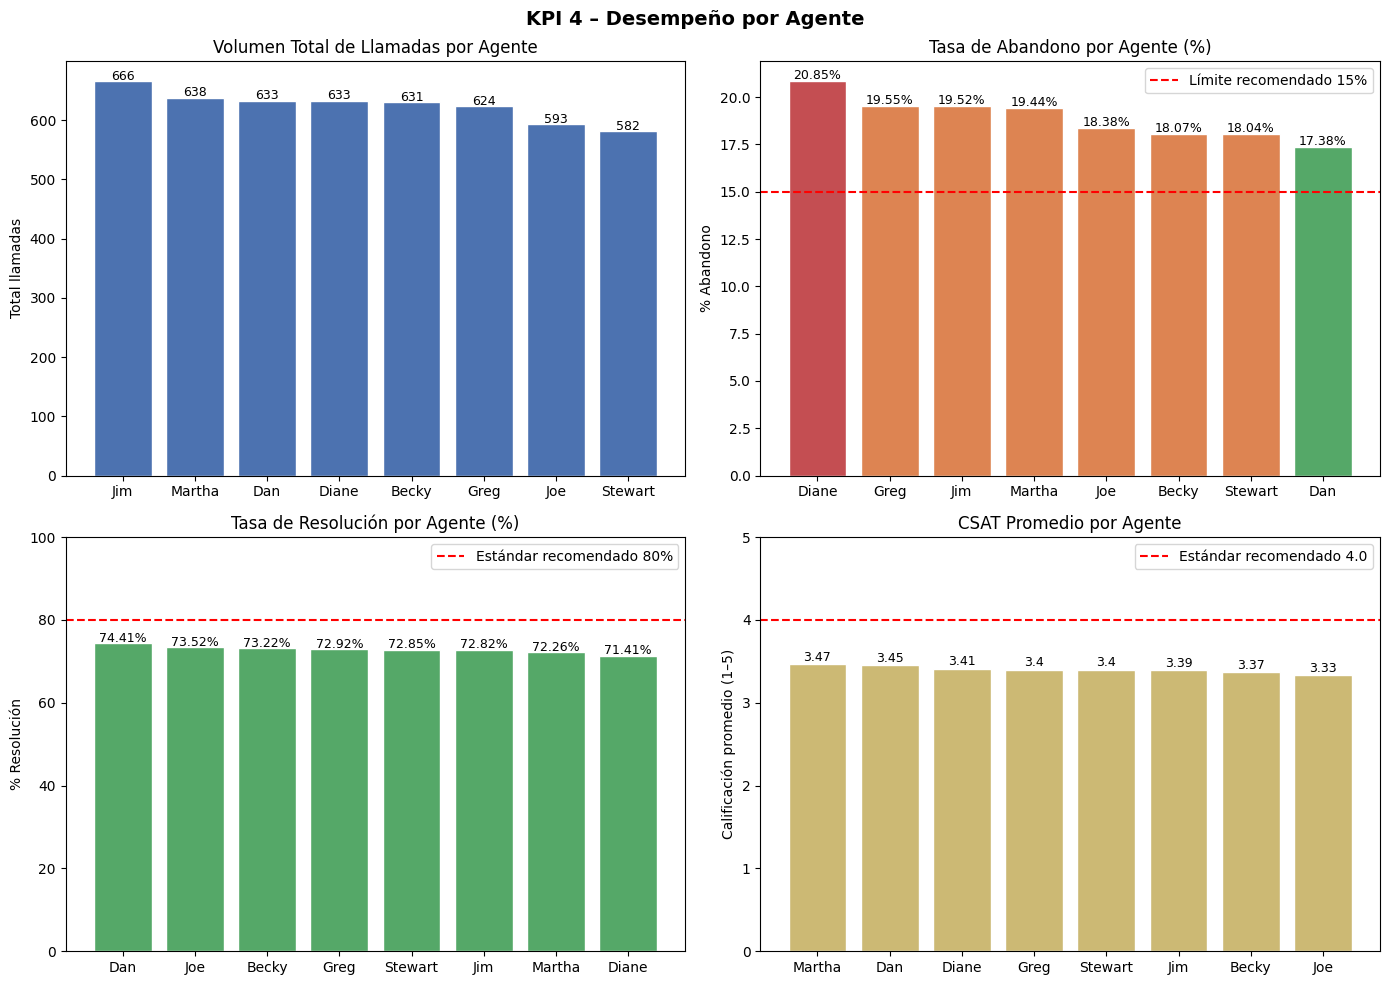

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('KPI 4 – Desempeño por Agente', fontsize=14, fontweight='bold')

kpi4_sorted_vol = kpi4.sort_values('Total_Llamadas', ascending=False)

# Volumen total
axes[0,0].bar(kpi4_sorted_vol['Agent'], kpi4_sorted_vol['Total_Llamadas'], color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Volumen Total de Llamadas por Agente')
axes[0,0].set_ylabel('Total llamadas')
for i, (ag, val) in enumerate(zip(kpi4_sorted_vol['Agent'], kpi4_sorted_vol['Total_Llamadas'])):
    axes[0,0].text(i, val + 2, str(val), ha='center', fontsize=9)

# Tasa de abandono
kpi4_sorted_ab = kpi4.sort_values('Tasa_Abandono_%', ascending=False)
colores_ab = ['#C44E52' if v > 20 else '#DD8452' if v > 18 else '#55A868' for v in kpi4_sorted_ab['Tasa_Abandono_%']]
axes[0,1].bar(kpi4_sorted_ab['Agent'], kpi4_sorted_ab['Tasa_Abandono_%'], color=colores_ab, edgecolor='white')
axes[0,1].axhline(15, color='red', linestyle='--', linewidth=1.5, label='Límite recomendado 15%')
axes[0,1].set_title('Tasa de Abandono por Agente (%)')
axes[0,1].set_ylabel('% Abandono')
axes[0,1].legend()
for i, (ag, val) in enumerate(zip(kpi4_sorted_ab['Agent'], kpi4_sorted_ab['Tasa_Abandono_%'])):
    axes[0,1].text(i, val + 0.1, f'{val}%', ha='center', fontsize=9)

# Tasa de resolución
kpi4_sorted_res = kpi4.sort_values('Tasa_Resolucion_%', ascending=False)
axes[1,0].bar(kpi4_sorted_res['Agent'], kpi4_sorted_res['Tasa_Resolucion_%'], color='#55A868', edgecolor='white')
axes[1,0].axhline(80, color='red', linestyle='--', linewidth=1.5, label='Estándar recomendado 80%')
axes[1,0].set_title('Tasa de Resolución por Agente (%)')
axes[1,0].set_ylabel('% Resolución')
axes[1,0].set_ylim(0, 100)
axes[1,0].legend()
for i, (ag, val) in enumerate(zip(kpi4_sorted_res['Agent'], kpi4_sorted_res['Tasa_Resolucion_%'])):
    axes[1,0].text(i, val + 0.3, f'{val}%', ha='center', fontsize=9)

# CSAT por agente
kpi4_sorted_csat = kpi4.sort_values('CSAT_prom', ascending=False)
axes[1,1].bar(kpi4_sorted_csat['Agent'], kpi4_sorted_csat['CSAT_prom'], color='#CCB974', edgecolor='white')
axes[1,1].axhline(4.0, color='red', linestyle='--', linewidth=1.5, label='Estándar recomendado 4.0')
axes[1,1].set_title('CSAT Promedio por Agente')
axes[1,1].set_ylabel('Calificación promedio (1–5)')
axes[1,1].set_ylim(0, 5)
axes[1,1].legend()
for i, (ag, val) in enumerate(zip(kpi4_sorted_csat['Agent'], kpi4_sorted_csat['CSAT_prom'])):
    axes[1,1].text(i, val + 0.04, f'{val}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretación de negocio:**  
La carga de trabajo está distribuida de manera relativamente equitativa entre los 8 agentes (582–666 llamadas). Sin embargo, Diane registra la tasa de abandono más alta (20.85%) y la tasa de resolución más baja (71.41%), lo que la convierte en el agente con mayor riesgo operativo; se recomienda una intervención de capacitación focalizada. Dan y Joe muestran el mejor balance entre resolución y satisfacción del cliente.

---
## Resumen Ejecutivo de KPIs

| KPI | Métrica | Valor obtenido | Referencia industria | Estado |
|-----|---------|---------------|----------------------|--------|
| KPI 1 – CR | Tasa de Resolución Global | 72.92% | ≥ 80% | ⚠️ Por debajo |
| KPI 1 – CR | CR sobre llamadas contestadas | 89.94% | ≥ 90% | ⚠️ Límite |
| KPI 2 – ASA | Tiempo promedio de respuesta | 67.52 seg | ≤ 60 seg | ⚠️ Por encima |
| KPI 3 – CSAT | Satisfacción promedio | 3.40 / 5.00 | ≥ 4.00 | ❌ Bajo |
| KPI 4 | Tasa de abandono más alta | Diane: 20.85% | ≤ 15% | ❌ Crítico |
| KPI 4 | Tasa de resolución más alta | Dan: 74.41% | ≥ 80% | ⚠️ Por debajo |

**Conclusión general:**  
Los cuatro KPIs analizados revelan un centro de contacto que opera por debajo de los estándares óptimos de la industria. El principal cuello de botella es el tiempo de espera elevado (ASA = 67.52 seg), que impulsa la tasa de abandono del 18.92% y deprime la satisfacción del cliente (CSAT = 3.40). Para revertir esta situación, se recomienda: (1) incrementar la capacidad de agentes en horas pico, (2) implementar un sistema de enrutamiento inteligente de llamadas, y (3) reforzar la capacitación de los agentes con mayor tasa de abandono, particularmente Diane.